# Notebook 05 — Crypto Derivatives: Deribit BTC/ETH Calibration

Fetches a live BTC or ETH option snapshot from Deribit REST API,
builds an IV surface, and calibrates the Rough Heston model.

**Runtime estimate:** 1–3 min (live network required)

In [1]:
import os, sys
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), "src") if os.path.basename(os.getcwd()) == "notebooks"
                else os.path.join(os.getcwd(), "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import torch

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelsize": 11,
    "font.family": "serif",
})
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")


from market.deribit_data import fetch_option_snapshot, build_iv_surface, calibrate_crypto
from fno_model import MirrorPaddedFNO2d
from calibrate import _load_normalizers


Device: cuda


## 1. Fetch Live Option Snapshot from Deribit

In [2]:
CURRENCY = "BTC"   # or "ETH"

# Jupyter already runs an asyncio event loop — use 'await' directly
df = await fetch_option_snapshot(CURRENCY)
print(f"Fetched {len(df)} live {CURRENCY} options from Deribit")
print(f"Columns: {df.columns.tolist()}")
print(df[["instrument_name","expiry","strike","mark_iv","log_moneyness"]].head(10).to_string())


Fetched 548 live BTC options from Deribit
Columns: ['instrument_name', 'coin', 'expiry', 'strike', 'option_type', 'mark_iv', 'bid_iv', 'ask_iv', 'underlying_price', 'open_interest', 'mark_price', 'log_moneyness', 'T']
        instrument_name      expiry    strike  mark_iv  log_moneyness
0   BTC-31JUL26-69000-C  2026-07-31   69000.0   0.3524       0.070269
1   BTC-31JUL26-65000-C  2026-07-31   65000.0   0.3740       0.010550
2   BTC-31JUL26-50000-C  2026-07-31   50000.0   0.5486      -0.251815
3  BTC-31JUL26-108000-P  2026-07-31  108000.0   0.5886       0.518294
4   BTC-31JUL26-73000-C  2026-07-31   73000.0   0.3453       0.126622
5   BTC-31JUL26-98000-C  2026-07-31   98000.0   0.5094       0.421130
6   BTC-31JUL26-84000-C  2026-07-31   84000.0   0.3860       0.266979
7  BTC-31JUL26-115000-C  2026-07-31  115000.0   0.6310       0.581095
8   BTC-31JUL26-81000-C  2026-07-31   81000.0   0.3664       0.230612
9   BTC-31JUL26-77000-C  2026-07-31   77000.0   0.3485       0.179968


## 2. Build the IV Surface

In [3]:
from market.spx_data import T_GRID, K_GRID
iv_surface = build_iv_surface(df, currency=CURRENCY)   # shape (8, 11)
T_nodes, K_nodes = T_GRID, K_GRID
print(f"Maturities (yr): {np.round(T_nodes, 3)}")
print(f"Log-moneyness:   {np.round(K_nodes, 2)}")
print(f"ATM vol range:   {iv_surface[:, 5].min()*100:.1f}% — "
      f"{iv_surface[:, 5].max()*100:.1f}%")


Maturities (yr): [0.1 0.3 0.6 0.9 1.2 1.5 1.8 2. ]
Log-moneyness:   [-0.5 -0.4 -0.3 -0.2 -0.1  0.   0.1  0.2  0.3  0.4  0.5]
ATM vol range:   38.2% — 43.4%


## 3. Plot the Live IV Surface

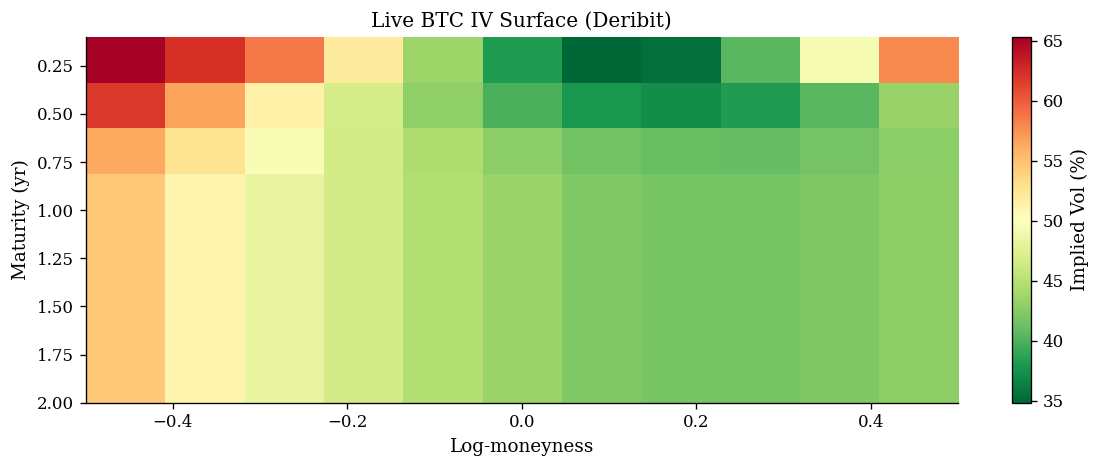

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(iv_surface * 100, aspect="auto", cmap="RdYlGn_r",
               extent=[K_nodes[0], K_nodes[-1], T_nodes[-1], T_nodes[0]])
ax.set_xlabel("Log-moneyness"); ax.set_ylabel("Maturity (yr)")
ax.set_title(f"Live {CURRENCY} IV Surface (Deribit)")
plt.colorbar(im, label="Implied Vol (%)"); plt.tight_layout(); plt.show()


## 4. Calibrate Rough Heston to Crypto

Uses the dedicated `calibrate_crypto()` function which handles the
parameter range adjustments needed for BTC/ETH (higher vol-of-vol, wider grid).

In [5]:
# calibrate_crypto handles model loading and normalizer setup internally
result = calibrate_crypto(currency=CURRENCY)
print(f"\nCalibration RMSE: {result['rmse_bps']:.1f} bps")
print(f"Converged:        {result.get('converged', 'N/A')}")
print(f"Params clipped:   {result.get('params_clipped', False)}")
for name in ['v0', 'sigma', 'rho', 'zeta', 'lambda', 'H']:
    if name in result:
        print(f"  {name:6s} = {result[name]:.4f}")


[BTC] Model loaded: fno_v2_final_prod.pth on cuda
[BTC] Fetching Deribit option snapshot ...


[BTC] Snapshot: 548 options after filtering
[BTC] Running Newton calibration ...


  [ 0] loss=4.98e-03  θ=[0.1400,-0.2500,0.3500]


  [ 1] loss=4.21e-03  θ=[0.1500,-0.2925,0.5576]
  [ 2] loss=4.21e-03  θ=[0.1500,-0.2925,0.5576]
  [ 3] loss=4.21e-03  θ=[0.1500,-0.2925,0.5576]
  [ 4] loss=4.21e-03  θ=[0.1500,-0.2925,0.5576]
  [ 5] loss=4.21e-03  θ=[0.1500,-0.2925,0.5576]
  [ 6] loss=4.21e-03  θ=[0.1500,-0.2925,0.5576]
  [ 7] loss=4.21e-03  θ=[0.1500,-0.2925,0.5576]


  [ 8] loss=4.21e-03  θ=[0.1500,-0.2925,0.5576]
  [ 9] loss=4.21e-03  θ=[0.1500,-0.2925,0.5576]
  [10] loss=4.21e-03  θ=[0.1500,-0.2925,0.5576]
  [11] loss=4.21e-03  θ=[0.1500,-0.2925,0.5576]
  [12] loss=4.21e-03  θ=[0.1500,-0.2925,0.5576]
  [13] loss=4.21e-03  θ=[0.1500,-0.2925,0.5576]


...

  [ 2] loss=4.24e-03  θ=[0.1500,-0.2310,0.6417]
  [ 3] loss=4.24e-03  θ=[0.1500,-0.2310,0.6417]
  [ 4] loss=4.24e-03  θ=[0.1500,-0.2310,0.6417]
  [ 5] loss=4.24e-03  θ=[0.1500,-0.2310,0.6417]
  [ 6] loss=4.24e-03  θ=[0.1500,-0.2310,0.6417]
  [ 7] loss=4.24e-03  θ=[0.1500,-0.2310,0.6417]
  [ 8] loss=4.24e-03  θ=[0.1500,-0.2310,0.6417]


  [ 9] loss=4.24e-03  θ=[0.1500,-0.2310,0.6417]
  [10] loss=4.24e-03  θ=[0.1500,-0.2310,0.6417]
  [11] loss=4.24e-03  θ=[0.1500,-0.2310,0.6417]
  [12] loss=4.24e-03  θ=[0.1500,-0.2310,0.6417]
  [13] loss=4.24e-03  θ=[0.1500,-0.2310,0.6417]
  [14] loss=4.24e-03  θ=[0.1500,-0.2310,0.6417]
  [15] loss=4.24e-03  θ=[0.1500,-0.2310,0.6417]


  [16] loss=4.24e-03  θ=[0.1500,-0.2310,0.6417]
  [17] loss=4.24e-03  θ=[0.1500,-0.2310,0.6417]
  [18] loss=4.24e-03  θ=[0.1500,-0.2310,0.6417]
  [19] loss=4.24e-03  θ=[0.1500,-0.2310,0.6417]
  [ 0] loss=7.99e-03  θ=[0.1400,-0.4000,0.2500]
  [ 1] loss=5.90e-03  θ=[0.1500,-0.4251,0.4788]
  [ 2] loss=5.35e-03  θ=[0.1500,-0.3920,0.6009]
  [ 3] loss=5.24e-03  θ=[0.1500,-0.3719,0.6878]
  [ 4] loss=5.14e-03  θ=[0.1500,-0.3525,0.7300]


  [ 5] loss=5.07e-03  θ=[0.1500,-0.3421,0.7415]
  [ 6] loss=5.03e-03  θ=[0.1500,-0.3396,0.7388]
  [ 7] loss=5.02e-03  θ=[0.1500,-0.3387,0.7373]
  [ 8] loss=5.01e-03  θ=[0.1500,-0.3383,0.7365]
  [ 9] loss=5.01e-03  θ=[0.1500,-0.3381,0.7361]
  [10] loss=5.01e-03  θ=[0.1500,-0.3381,0.7360]
  [11] loss=5.01e-03  θ=[0.1500,-0.3380,0.7359]
  [12] loss=5.01e-03  θ=[0.1500,-0.3380,0.7358]
  [13] loss=5.01e-03  θ=[0.1500,-0.3380,0.7358]
  [14] loss=5.01e-03  θ=[0.1500,-0.3380,0.7358]
  [15] loss=5.01e-03  θ=[0.1500,-0.3380,0.7358]
  [16] loss=5.01e-03  θ=[0.1500,-0.3380,0.7358]
  [17] loss=5.01e-03  θ=[0.1500,-0.3380,0.7358]


  [18] loss=5.01e-03  θ=[0.1500,-0.3380,0.7358]
  [19] loss=5.01e-03  θ=[0.1500,-0.3380,0.7358]

[BTC] Calibration result:
  v0     = 0.1500
  sigma  = 0.6297
  rho    = -0.4645
  RMSE   = 648.9 bps
  iters  = 20
  time   = 2.59s

Calibration RMSE: 648.9 bps
Converged:        N/A
Params clipped:   False
  v0     = 0.1500
  sigma  = 0.6297
  rho    = -0.4645
  zeta   = -0.2925
  lambda = 0.5576
  H      = 0.0800


## 5. Market vs Model Overlay

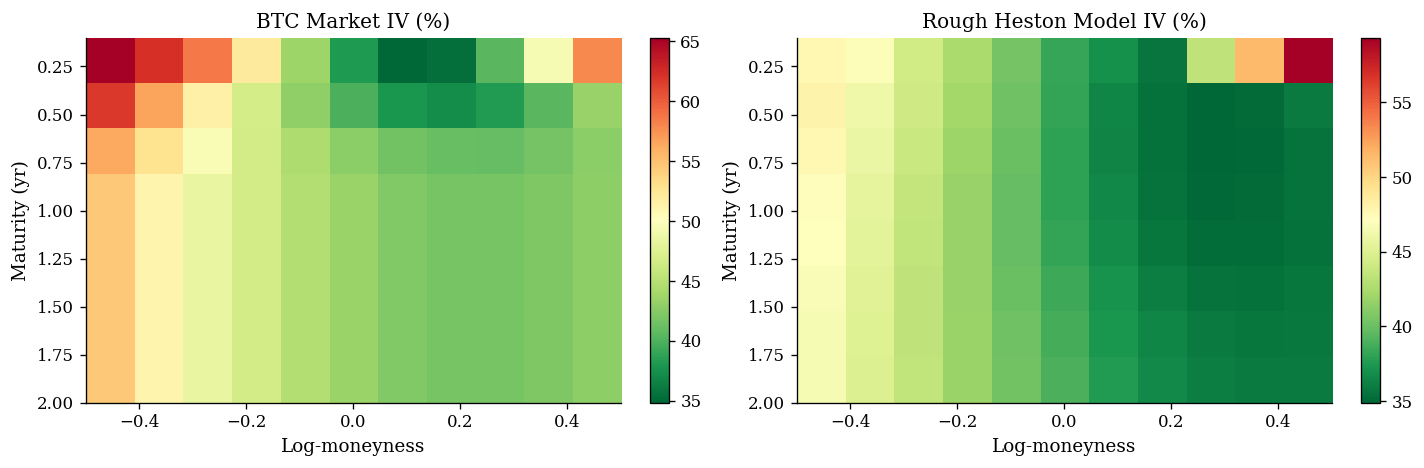

Max |residual|: 1764.8 bps


In [6]:
pred = result.get("iv_fitted")   # (8,11) model-predicted surface from calibrate_newton_h
if pred is not None and pred.shape == iv_surface.shape:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, data, title in zip(axes,
            [iv_surface*100, pred*100],
            [f"{CURRENCY} Market IV (%)", "Rough Heston Model IV (%)"]):
        im = ax.imshow(data, aspect="auto", cmap="RdYlGn_r",
                       extent=[K_nodes[0], K_nodes[-1], T_nodes[-1], T_nodes[0]])
        ax.set_title(title); ax.set_xlabel("Log-moneyness")
        ax.set_ylabel("Maturity (yr)")
        plt.colorbar(im, ax=ax, fraction=0.04)
    plt.tight_layout(); plt.show()
    residuals = (pred - iv_surface) * 1e4
    print(f"Max |residual|: {np.abs(residuals).max():.1f} bps")
else:
    print("Model surface not available — check calibrate_crypto return value")
